# Session 1b: Visual EDA
**Emission-trajectory ML project. Dr. Khawar Naeem, QTTSC, Qatar University.**

This notebook turns the Session 1 findings (`01_framing_eda.ipynb`) into figures. Every figure states one modeling consequence, because each of these plots is the visual argument for a decision already locked in the frozen problem statement.

Figures are saved to `../results/figures/` so the README can cite them as saved artifacts, per the project rule that every quantitative claim ties to a saved result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/raw/owid-co2-data.csv")
is_country = df["iso_code"].notna() & ~df["iso_code"].astype(str).str.startswith("OWID")
countries = df[is_country].copy()
print(countries["country"].nunique(), "countries")

218 countries


## Figure 1. The skew: why the mean country does not exist

2023 emissions across countries, on a log x-axis. On a linear axis this histogram would be one bar near zero and a few invisible dots; the log scale is what makes a five-orders-of-magnitude variable readable.

The mean (172 Mt) sits far to the right of the median (10.5 Mt) because China, the US, and a few others drag it. **Modeling consequence:** overall MAE is dominated by giants, so the evaluation plan requires median errors, percentage errors, and emitter-size tiers.

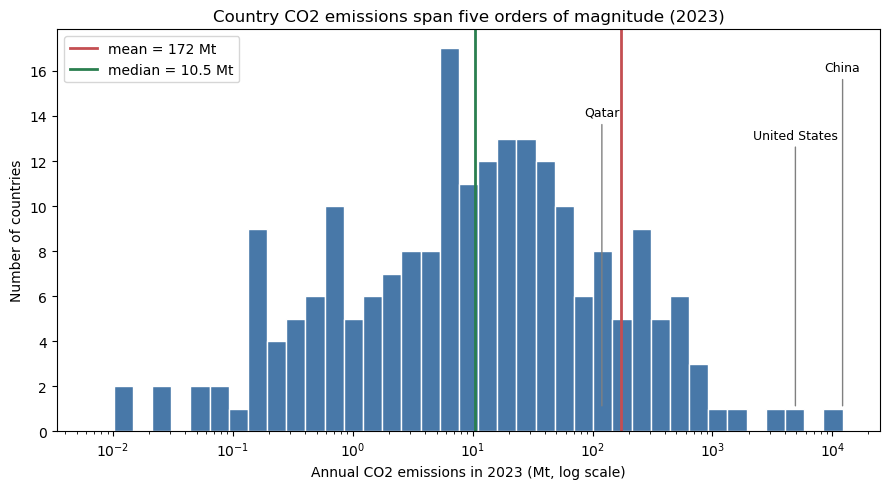

In [2]:
lvl = countries[(countries["year"] == 2023) & countries["co2"].notna()].set_index("country")["co2"]
pos = lvl[lvl > 0]

fig, ax = plt.subplots(figsize=(9, 5))
bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 40)
ax.hist(pos, bins=bins, color="#4878a8", edgecolor="white")
ax.set_xscale("log")
ax.axvline(lvl.mean(), color="#c44e52", lw=2, label=f"mean = {lvl.mean():.0f} Mt")
ax.axvline(lvl.median(), color="#2a7f4f", lw=2, label=f"median = {lvl.median():.1f} Mt")
label_heights = {"China": 16, "United States": 13, "Qatar": 14}
for name, h in label_heights.items():
    ax.annotate(name, xy=(lvl[name], 1), xytext=(lvl[name], h),
                ha="center", fontsize=9, arrowprops=dict(arrowstyle="-", color="gray"))
ax.set_xlabel("Annual CO2 emissions in 2023 (Mt, log scale)")
ax.set_ylabel("Number of countries")
ax.set_title("Country CO2 emissions span five orders of magnitude (2023)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_distribution_skew.png", dpi=150)
plt.show()

## Figure 2. Concentration: the top-5 problem

Top-10 emitters in 2023 with each country's share of the world total. The top 5 alone are 62%. **Modeling consequence:** a model that only fits China and the US well can look excellent on overall MAE while being useless for the median country; size-tier reporting catches this.

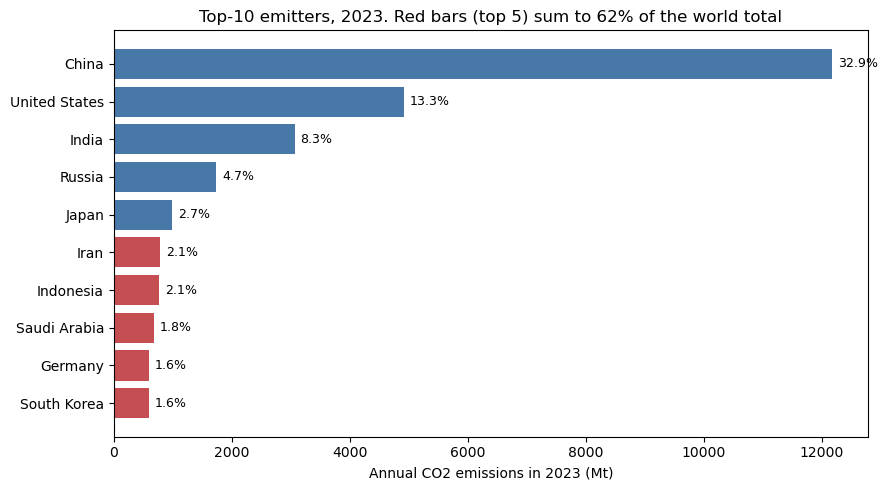

In [3]:
top10 = lvl.nlargest(10)
share = top10 / lvl.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index[::-1], top10[::-1], color=["#c44e52" if i >= 5 else "#4878a8" for i in range(9, -1, -1)])
for name, val in top10.items():
    ax.text(val + 100, name, f"{share[name]:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Annual CO2 emissions in 2023 (Mt)")
ax.set_title("Top-10 emitters, 2023. Red bars (top 5) sum to 62% of the world total")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_top10_concentration.png", dpi=150)
plt.show()

## Figure 3. Persistence: the baseline to beat

Distribution of the absolute year-over-year change as a percentage of the level, all country-years since 2010. Half of all country-years move less than 4.4%. **Modeling consequence:** "predict last year's value" is already a strong forecast; every model is scored with a skill score against it.

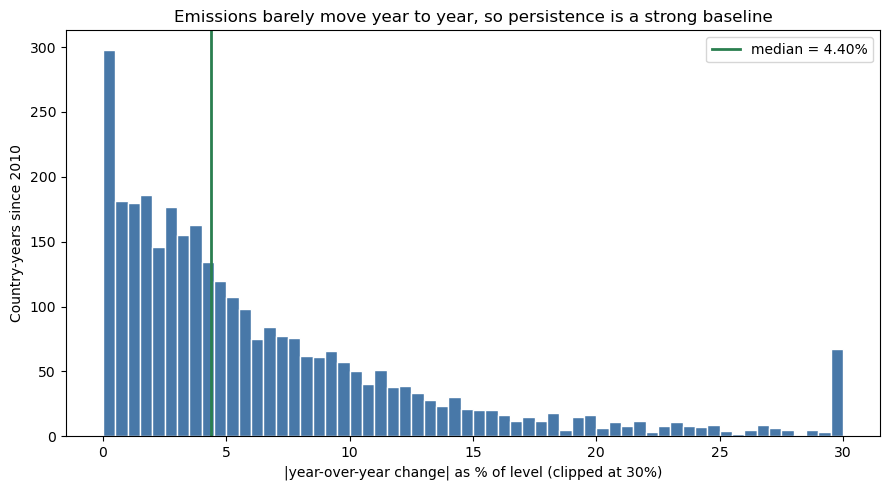

In [4]:
c = countries.sort_values(["country", "year"]).copy()
c["yoy_change"] = c.groupby("country")["co2"].diff()
recent = c[(c["year"] >= 2010) & c["yoy_change"].notna() & (c["co2"] > 0)]
rel = (recent["yoy_change"].abs() / recent["co2"]) * 100
med = rel.median()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(rel.clip(upper=30), bins=60, color="#4878a8", edgecolor="white")
ax.axvline(med, color="#2a7f4f", lw=2, label=f"median = {med:.2f}%")
ax.set_xlabel("|year-over-year change| as % of level (clipped at 30%)")
ax.set_ylabel("Country-years since 2010")
ax.set_title("Emissions barely move year to year, so persistence is a strong baseline")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_persistence_yoy.png", dpi=150)
plt.show()

## Figure 4. Missingness: the two-wave feature map

Percent missing per candidate feature column (country rows, 1990+), now including the energy family. Green = Wave 1 (use now, drop the few missing rows). Orange = Wave 2 (needs explicit missing-data handling). **Modeling consequence:** feature choice here is a data-quality decision made before any model exists.

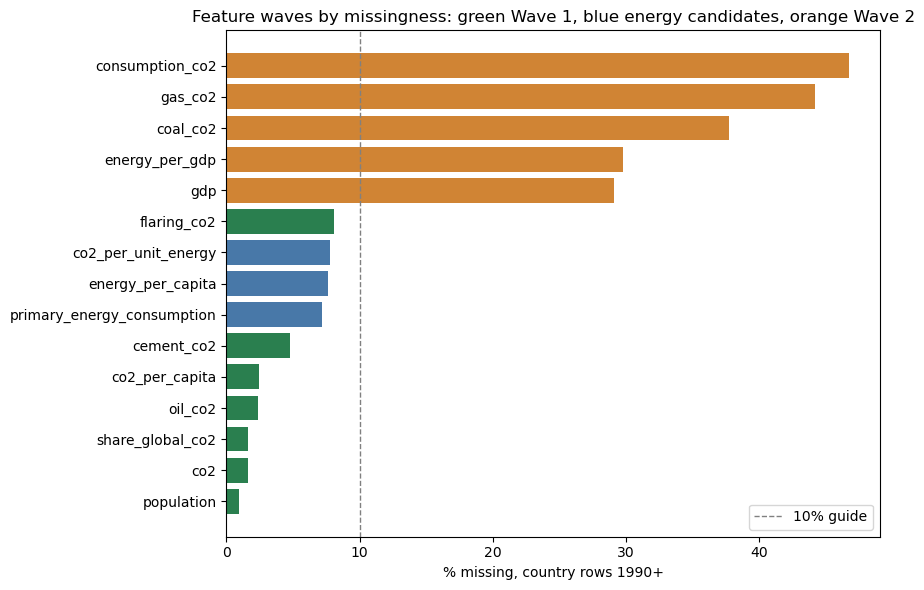

In [5]:
modern = countries[countries["year"] >= 1990]
wave1 = ["population", "co2", "share_global_co2", "oil_co2", "co2_per_capita", "cement_co2", "flaring_co2"]
wave2 = ["gdp", "coal_co2", "gas_co2", "consumption_co2", "energy_per_gdp"]
energy_candidates = ["primary_energy_consumption", "energy_per_capita", "co2_per_unit_energy"]
cols = wave1 + energy_candidates + wave2
miss = modern[cols].isna().mean().mul(100).sort_values()

def color(col):
    if col in wave1:
        return "#2a7f4f"
    if col in energy_candidates:
        return "#4878a8"
    return "#d08434"

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(miss.index, miss.values, color=[color(x) for x in miss.index])
ax.axvline(10, color="gray", ls="--", lw=1, label="10% guide")
ax.set_xlabel("% missing, country rows 1990+")
ax.set_title("Feature waves by missingness: green Wave 1, blue energy candidates, orange Wave 2")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_missingness_waves.png", dpi=150)
plt.show()

## Figure 5. Energy and emissions move together

Primary energy consumption vs. CO2 emissions, 2023, log-log. The near-linear cloud shows how tightly national emissions track national energy use; countries below the trend burn cleaner energy per unit (more renewables, nuclear, gas instead of coal). **Modeling consequence:** energy columns (7-8% missing) are strong feature candidates for the CO2 model. Predicting energy itself is a gated extension after the CO2 model ships, since the pipeline is target-agnostic.

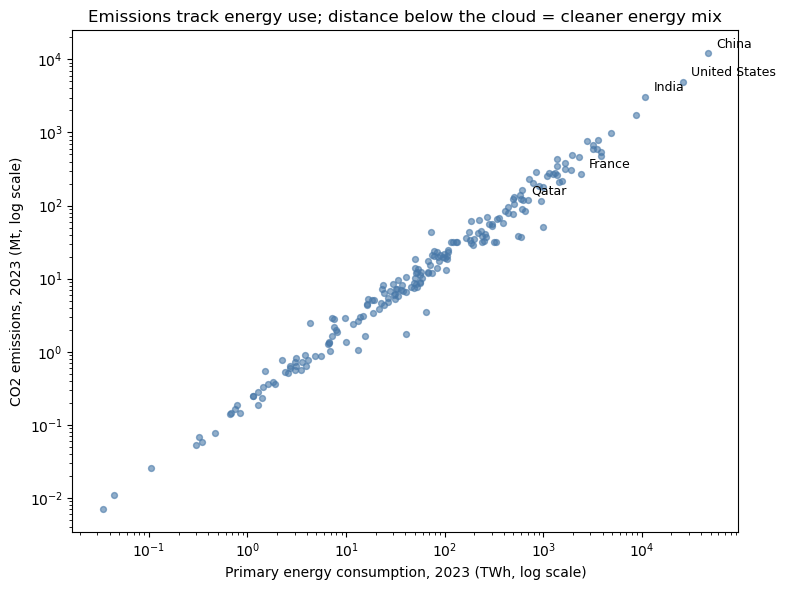

In [6]:
snap = countries[(countries["year"] == 2023) & countries["co2"].notna() & countries["primary_energy_consumption"].notna()]
snap = snap[(snap["co2"] > 0) & (snap["primary_energy_consumption"] > 0)]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(snap["primary_energy_consumption"], snap["co2"], s=18, alpha=0.6, color="#4878a8")
for name in ["China", "United States", "Qatar", "France", "India"]:
    row = snap[snap["country"] == name]
    if len(row):
        ax.annotate(name, (row["primary_energy_consumption"].iloc[0], row["co2"].iloc[0]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Primary energy consumption, 2023 (TWh, log scale)")
ax.set_ylabel("CO2 emissions, 2023 (Mt, log scale)")
ax.set_title("Emissions track energy use; distance below the cloud = cleaner energy mix")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_energy_vs_co2.png", dpi=150)
plt.show()

## Figure 6. The sanity anchor: Qatar

Qatar's CO2 trajectory since 1990, with the 2020 COVID-era dip marked. This is the series used to hand-verify the Session 2 target shift (the 2023 row must carry 2024's value, 125.8 Mt, as its target). **Modeling consequence:** one country you know well, checked by eye, catches off-by-one shift bugs that metrics never will.

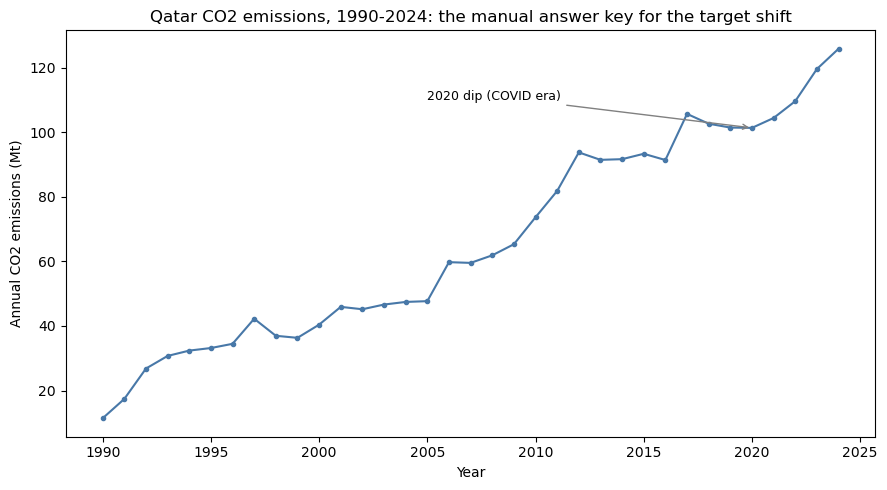

In [7]:
qat = countries[(countries["country"] == "Qatar") & (countries["year"] >= 1990)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(qat["year"], qat["co2"], marker="o", ms=3, color="#4878a8")
dip = qat[qat["year"] == 2020]
ax.annotate("2020 dip (COVID era)", xy=(2020, dip["co2"].iloc[0]),
            xytext=(2005, 110), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_xlabel("Year")
ax.set_ylabel("Annual CO2 emissions (Mt)")
ax.set_title("Qatar CO2 emissions, 1990-2024: the manual answer key for the target shift")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_qatar_anchor.png", dpi=150)
plt.show()

## What these six figures argue, together

1. The variable is extremely skewed (fig 1) and concentrated (fig 2), so evaluation must be scale-aware.
2. The variable barely moves year to year (fig 3), so persistence is the honest bar to clear.
3. Feature availability, not preference, dictates the two-wave feature plan (fig 4).
4. Energy data is well populated and tightly coupled to emissions (fig 5), so it joins as features first; predicting energy itself is a later, gated extension using the same pipeline.
5. Qatar (fig 6) is the by-eye verification anchor for Session 2.

## References

Our World in Data CO2 dataset repository: https://github.com/owid/co2-data

Matplotlib documentation: https://matplotlib.org/stable/
